# GRAIL — Graph Exploration & Visualization

This notebook mirrors the integration test suite
(`tests/integration/test_grail_exploration.py`) and adds interactive graph
visualizations using **pyvis**, **matplotlib**, and the built-in **Sigma.js**
HTML viewer.

**Prerequisites:**
- The quickstart project has been indexed: `grail index examples/quickstart`
- `DEEPINFRA_API_KEY` is set (via `.env` or environment)

**Sections:**
1. Requirements & Setup
2. Config Validation (mirrors `TestConfig`)
3. Storage Layer (mirrors `TestStorage`)
4. Artifact Schemas (mirrors `TestArtifactSchemas`)
5. Graph Structure — NetworkX (mirrors `TestGraph`)
6. Graph Visualization — matplotlib
7. Graph Visualization — pyvis (interactive HTML)
8. Sigma.js Viewer (built-in `graph.html`)
9. Retrieval Primitives (mirrors `TestRetrievalPrimitives`)
10. GRAIL High-Level API (mirrors `TestGRAILHighLevel`)
11. Provenance Tracing (mirrors `TestProvenance`)
12. Cost Tracking (mirrors `TestCostTracker`)

## 1. Requirements & Setup

Install notebook-specific dependencies (pyvis for interactive graphs,
matplotlib for static plots). The core GRAIL deps are already in
`pyproject.toml`.

```
pip install grail[notebook]
```

Or install individually:

In [47]:
# Uncomment to install notebook extras if not already present.
# !pip install pyvis matplotlib ipywidgets

In [48]:
import sys, os, json
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv

QUICKSTART = REPO_ROOT / "examples" / "quickstart"
QUICKSTART_YAML = QUICKSTART / "grail.yaml"
load_dotenv(QUICKSTART / ".env")

import pandas as pd
import networkx as nx
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

print(f"Repo root:  {REPO_ROOT}")
print(f"Quickstart: {QUICKSTART}")
print(f"Config:     {QUICKSTART_YAML} (exists={QUICKSTART_YAML.exists()})")
print(f"API key:    {'set' if 'DEEPINFRA_API_KEY' in os.environ else 'MISSING'}")

Repo root:  /Users/bgg/Documents/repos/cchia/opensource_comission/projects/GRAIL
Quickstart: /Users/bgg/Documents/repos/cchia/opensource_comission/projects/GRAIL/examples/quickstart
Config:     /Users/bgg/Documents/repos/cchia/opensource_comission/projects/GRAIL/examples/quickstart/grail.yaml (exists=True)
API key:    MISSING


In [49]:
from grail import GRAIL, Config, SearchResult, load_config
from grail.config import MANDATORY_ENTITY_TYPES
from grail.indexing import (
    CommunityExtractor,
    CommunityReportGenerator,
    EntityRelationshipExtractor,
    FileLoader,
    IncrementalCommunityExtractor,
)
from grail.indexing.run_manifest import resolve_active_run_folder
from grail.query import (
    AgentSearch,
    DocumentSearch,
    GlobalSearch,
    LocalSearch,
    load_artifacts_for_search,
    map_query_to_entities,
)
from grail.query.retrieval import (
    SearchArtifacts,
    build_community_context,
    build_entity_context,
    build_relationship_context,
    build_text_unit_context,
)
from grail.storage import LocalStorage

config = load_config(QUICKSTART_YAML)
grail_instance = GRAIL.from_config(config)
storage = LocalStorage(root=config.storage.root)

# Resolve the active run folder (latest indexed run from current.json).
output_folder = grail_instance._output_folder()
artifacts = load_artifacts_for_search(grail_instance.storage, output_folder)

# Show the resolved run path so it's clear which artefacts we're reading.
run_root = Path(config.storage.root) / output_folder
current_json = Path(config.storage.root) / config.indexing.output_folder / "current.json"
if current_json.exists():
    current = json.loads(current_json.read_text())
    print(f"Active run:   {current.get('run_id', '?')}")
    print(f"Operation:    {current.get('operation', '?')}")
    print(f"Updated at:   {current.get('updated_at', '?')}")
print(f"Run folder:   {run_root}")
print(f"Project:      {config.project_name}")
print(f"LLM:          {config.llm.endpoint} | {config.llm.model}")
print(f"Embeddings:   {config.embeddings.endpoint} | {config.embeddings.model}")
print(f"Entity types: {config.indexing.entity_types}")

# List artefact files in the run folder.
if run_root.exists():
    print(f"\nArtefact files in {run_root.name}/:")
    for f in sorted(run_root.iterdir()):
        size = f.stat().st_size
        label = f"{size/1024:.1f} KB" if size > 1024 else f"{size} B"
        print(f"  {f.name:45s} {label}")

Active run:   2026-05-21T20-01-05-40e8a
Operation:    index
Updated at:   2026-05-21T20:06:42+00:00
Run folder:   /Users/bgg/Documents/repos/cchia/opensource_comission/projects/GRAIL/examples/quickstart/output/runs/2026-05-21T20-01-05-40e8a
Project:      quickstart
LLM:          deepinfra | Qwen/Qwen3.6-35B-A3B
Embeddings:   deepinfra | Qwen/Qwen3-Embedding-0.6B
Entity types: ['PERSON', 'ORGANIZATION', 'DISEASE', 'SYMPTOM', 'TREATMENT', 'DRUG', 'CLINICAL_STUDY', 'GUIDELINE', 'BIOMARKER', 'PATIENT_POPULATION']

Artefact files in 2026-05-21T20-01-05-40e8a/:
  entity_relationship_graph.graphml             11161.4 KB
  final_communities.parquet                     44.6 KB
  final_community_reports.parquet               39.6 KB
  final_docs.parquet                            66.8 KB
  final_entities.parquet                        2632.7 KB
  final_nodes.parquet                           76.5 KB
  final_relationships.parquet                   83.3 KB
  final_text_units.parquet               

## 2. Config Validation

Mirrors `TestConfig` from the integration suite.

In [50]:
# test_load_config
assert config.project_name == "quickstart"
assert config.llm.endpoint == "deepinfra"
print(f"LLM model:       {config.llm.model}")
print(f"Embedding model: {config.embeddings.model}")

# test_mandatory_entity_types_injected
for t in MANDATORY_ENTITY_TYPES:
    assert t in config.indexing.entity_types, f"{t} should be force-injected"
print(f"Mandatory types present: {list(MANDATORY_ENTITY_TYPES)}")

# test_entity_types_upper_snake
for t in config.indexing.entity_types:
    assert t == t.upper(), f"Entity type {t!r} should be UPPER_SNAKE_CASE"
print(f"All entity types UPPER_SNAKE_CASE: {config.indexing.entity_types}")

# test_extra_pricing
key = f"deepinfra|{config.llm.model}"
if key in config.llm.extra_pricing:
    prompt, completion = config.llm.extra_pricing[key]
    print(f"Pricing for {key}: prompt=${prompt}, completion=${completion}")
else:
    print(f"No extra pricing for {key}")

# test_endpoints_populated
assert "deepinfra" in config.endpoints
ep = config.endpoints["deepinfra"]
print(f"Endpoint base_url: {ep.base_url}")

print("\nAll config checks passed.")

LLM model:       Qwen/Qwen3.6-35B-A3B
Embedding model: Qwen/Qwen3-Embedding-0.6B
Mandatory types present: ['PERSON', 'ORGANIZATION']
All entity types UPPER_SNAKE_CASE: ['PERSON', 'ORGANIZATION', 'DISEASE', 'SYMPTOM', 'TREATMENT', 'DRUG', 'CLINICAL_STUDY', 'GUIDELINE', 'BIOMARKER', 'PATIENT_POPULATION']
Pricing for deepinfra|Qwen/Qwen3.6-35B-A3B: prompt=$0.15, completion=$0.95
Endpoint base_url: https://api.deepinfra.com/v1/openai

All config checks passed.


## 3. Storage Layer

Mirrors `TestStorage` — validates the storage root and `mapping.json`.

In [51]:
# test_storage_root_exists
assert Path(storage.root).exists()
print(f"Storage root: {storage.root}")

# test_mapping_json_exists
assert storage.exists("mapping.json")

# test_mapping_json_schema
raw = storage.read_text("mapping.json")
mapping = json.loads(raw)
assert isinstance(mapping, dict)

print(f"\nmapping.json: {len(mapping)} documents")
for doc_id, info in mapping.items():
    assert isinstance(doc_id, str)
    assert "original_path" in info or "path" in info
    print(f"  {doc_id}: {info}")

print("\nAll storage checks passed.")

Storage root: /Users/bgg/Documents/repos/cchia/opensource_comission/projects/GRAIL/examples/quickstart

mapping.json: 2 documents
  18f6c53f-0d85-44a0-ad55-2d8fd6716497: {'original_path': 'input/SEOM_2023_cachexia.pdf', 'processed_path': 'input/_processed/SEOM_2023_cachexia.md', 'title': 'SEOM_2023_cachexia.pdf', 'extension': '.pdf', 'data_type': 'office', 'size_chars': 52411}
  4b192766-900c-420d-9f1d-9083eb8b5ebc: {'original_path': 'input/SEOM_2023_gliomas.pdf', 'processed_path': 'input/_processed/SEOM_2023_gliomas.md', 'title': 'SEOM_2023_gliomas.pdf', 'extension': '.pdf', 'data_type': 'office', 'size_chars': 54278}

All storage checks passed.


## 4. Artifact Schemas

Mirrors `TestArtifactSchemas` — validates every parquet has expected columns
and non-zero rows.

In [52]:
def check_columns(df, name, required_cols):
    """Assert required columns are present and the dataframe is non-empty."""
    assert not df.empty, f"{name} should not be empty"
    missing = required_cols - set(df.columns)
    assert not missing, f"{name} missing columns: {missing}"
    print(f"{name}: {len(df)} rows, columns={list(df.columns)}")

# Documents
check_columns(artifacts.documents, "documents",
    {"id", "title", "raw_content", "path", "text_unit_ids"})
print(f"  Titles: {artifacts.documents['title'].tolist()}")

# Text Units
check_columns(artifacts.text_units, "text_units",
    {"id", "text", "n_tokens", "document_ids", "entity_ids", "relationship_ids"})
print(f"  Token range: {artifacts.text_units['n_tokens'].min()} - {artifacts.text_units['n_tokens'].max()}")

# Entities
check_columns(artifacts.entities, "entities",
    {"id", "name", "type", "description", "description_embedding", "text_unit_ids", "degree"})
print(f"  Types: {sorted(artifacts.entities['type'].dropna().unique())}")

# Relationships
check_columns(artifacts.relationships, "relationships",
    {"id", "source", "target", "description", "weight", "text_unit_ids", "rank"})
print(f"  Weight range: {artifacts.relationships['weight'].min():.2f} - {artifacts.relationships['weight'].max():.2f}")

# Nodes
check_columns(artifacts.nodes, "nodes",
    {"title", "community", "level", "degree"})

# Communities
check_columns(artifacts.communities, "communities", set())

# Community Reports
check_columns(artifacts.community_reports, "community_reports", set())

print("\nAll artifact schema checks passed.")

documents: 2 rows, columns=['id', 'title', 'raw_content', 'path', 'text_unit_ids', 'mapping']
  Titles: ['SEOM_2023_cachexia.pdf', 'SEOM_2023_gliomas.pdf']
text_units: 22 rows, columns=['id', 'text', 'n_tokens', 'document_id', 'document_ids', 'entity_ids', 'relationship_ids']
  Token range: 881 - 1500
entities: 489 rows, columns=['id', 'name', 'title', 'type', 'description', 'human_readable_id', 'graph_embedding', 'text_unit_ids', 'document_ids', 'description_embedding', 'degree']
  Types: ['BIOMARKER', 'CLINICAL_STUDY', 'DISEASE', 'DRUG', 'GUIDELINE', 'ORGANIZATION', 'PATIENT_POPULATION', 'PERSON', 'SYMPTOM', 'TREATMENT']
relationships: 485 rows, columns=['id', 'source', 'target', 'source_id', 'target_id', 'description', 'weight', 'text_unit_ids', 'document_ids', 'human_readable_id', 'rank', 'source_degree', 'target_degree']
  Weight range: 5.00 - 10.00
nodes: 978 rows, columns=['level', 'community', 'title', 'id', 'type', 'description', 'degree', 'human_readable_id', 'source_id', 'si

In [58]:
artifacts.nodes

,level,community,title,id,type,description,degree,human_readable_id,source_id,size,graph_embedding,top_level_node_id,x,y
0,0,70,ANOREXIA,44d22b43-62c1-423e-8c2a-cd5f9f6ee33f,SYMPTOM,"Loss of appetite frequently associated with cachexia, often preceding measurable weight loss. Loss of appetite frequ...",6,18,"049ed98a-068c-4903-98ff-5ced7a3be647,25145b81-b147-48c5-9db2-d544859729ac,2babe520-1a30-4091-afe9-9ec359b775ac,503ef...",6,None,70,0,0
1,0,70,CANCER-ASSOCIATED CACHEXIA SYNDROME,19028bff-96b5-4ce1-b935-0ce700149345,DISEASE,"A syndrome characterized by cancer-related anorexia, weight loss, and muscle mass decline, often referred to as CACS.",12,96,503ef6a1-8e5b-4127-99f5-c803b63624c2,12,None,70,0,0
2,0,70,GLUCOCORTICOIDS,501c705c-1cbe-4028-86de-f15c8c131a45,DRUG,"A class of drugs used as first-line therapy to stimulate appetite in CACS patients, though efficacy declines with lo...",7,98,"503ef6a1-8e5b-4127-99f5-c803b63624c2,de094144-8633-45ff-aa63-63be5fc2b95a",7,None,70,0,0
3,0,70,PREDNISOLONE,1e22bd1a-f5d0-4d0d-b458-4739c7d2ce23,DRUG,A corticosteroid studied and utilized as an appetite stimulant in cancer care.,2,223,a2ab2c01-8a56-4a05-8a4d-d55927fb340d,2,None,70,0,0
4,0,70,PROGESTERONE ANALOGS,bf667afd-aeda-41a5-b65a-e428e5a4e776,DRUG,"Pharmacological agents demonstrated to improve appetite and body weight in cancer-related cachexia, primarily increa...",6,100,"503ef6a1-8e5b-4127-99f5-c803b63624c2,de094144-8633-45ff-aa63-63be5fc2b95a",6,None,70,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1,73,HIGH-RISK PATIENT GROUP,4ff8479d-336c-433b-8bc7-02112bb0456d,PATIENT_POPULATION,"Patients characterized by factors such as age ≥40, subtotal resection, or unfavorable molecular profiles, associated...",8,307,"522e3095-a145-4587-a200-32bf536ef8e4,cf750f3b-44b5-4a20-ab7a-becb440b2d7f",8,None,73,0,0
974,1,73,ADJUVANT RT,3a5f1528-e30f-4358-b0ba-4427d21a35fc,TREATMENT,"Postoperative radiotherapy administered to improve survival outcomes, particularly in high-risk grade 2 glioma patie...",2,301,522e3095-a145-4587-a200-32bf536ef8e4,2,None,73,0,0
975,1,73,RTOG 9802 PHASE III TRIAL,e12d3ef8-0664-4626-b9d6-86efe77b1513,CLINICAL_STUDY,A major randomized clinical trial evaluating the survival benefits of adding chemotherapy to radiotherapy in high-ri...,2,304,522e3095-a145-4587-a200-32bf536ef8e4,2,None,73,0,0
976,1,73,NEUROLOGIC DEFICIT,b9bcbd4c-9c80-43ab-a380-fd30ec50e4cb,SYMPTOM,"A clinical sign present prior to surgery, utilized in risk assessment scores like the Pignatti score to predict recu...",1,309,522e3095-a145-4587-a200-32bf536ef8e4,1,None,73,0,0


In [57]:
#t1 = "/Users/bgg/Downloads/Politica_de_IA_en_chile_107/output/final_entities.parquet"
t1 = "/Users/bgg/Downloads/Politica_de_IA_en_chile_107/output/final_nodes.parquet"
df_test = pd.read_parquet(t1)
df_test

,level,title,type,description,source_id,community,degree,human_readable_id,id,size,graph_embedding,top_level_node_id,x,y
0,1,"""RAIMUNDO ROBERTS M.""","""PERSON""","""Raimundo Roberts M. is the author of the expert consultation on the bill regulating artificial intelligence systems.""",23576513-cb8c-4a3b-acea-f082dbae9a93,68,1,0,e7eee0cc-2756-444a-b42e-6099da7ed621,1,None,68,0,0
1,1,"""PROYECTO DE LEY SOBRE SISTEMAS DE INTELIGENCIA ARTIFICIAL""","""PROJECT""","""A legislative project aimed at regulating artificial intelligence systems, identified by Bulletin 16821-19.""",23576513-cb8c-4a3b-acea-f082dbae9a93,68,5,1,e1e81e7e-5e6a-43c9-aa66-73e22e3e5a50,1,None,68,0,0
2,1,"""COMISIÓN DE FUTURO, CIENCIA, TECNOLOGÍA, CONOCIMIENTO E INNOVACIÓN""","""COMMITTEE""","The ""COMISIÓN DE FUTURO, CIENCIA, TECNOLOGÍA, CONOCIMIENTO E INNOVACIÓN"" is a committee within the Chamber of Deputi...","d132ecde-b939-4ef5-bc13-7effad8ca454,23576513-cb8c-4a3b-acea-f082dbae9a93",68,2,2,7c248f13-f117-4765-9222-0ed7dd77dc32,1,None,68,0,0
3,1,"""AGENCIA DE PROTECCIÓN DE DATOS PERSONALES""","""ORGANIZATION""","The ""AGENCIA DE PROTECCIÓN DE DATOS PERSONALES"" is a proposed agency in Chile tasked with overseeing compliance with...","02d30e26-3af9-4596-9358-95c3cb0ba281,f39c5bd3-4d7d-4c55-9975-3e49b05420cf,f832bf27-89a3-4f52-b926-28cc5f03e6e3,ec870...",68,10,3,39c78859-def9-4772-90d8-bab8364da476,1,None,68,0,0
4,1,"""RIESGO INACEPTABLE""","""RISK_CATEGORY""","The term ""RIESGO INACEPTABLE"" refers to a specific risk category within the context of artificial intelligence (AI) ...","23576513-cb8c-4a3b-acea-f082dbae9a93,82bd100a-abbf-4af6-bfaf-f83cd474d4e2,ac9dee10-a7d1-44dd-abfc-61e56ba64d79",68,4,4,6d62808d-b924-4de6-baf1-ddd38b03a57d,1,None,68,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,1,"""FUTURE SERIES: CYBERSECURITY, EMERGING TECHNOLOGY AND SYSTEMIC RISK""","""DOCUMENT""","""A report by the World Economic Forum addressing risks associated with emerging technologies.""",86f37714-8199-4127-8413-831d0a3bfbff,68,1,459,7a5bbe70-26f9-4cd0-8fb9-3aaa52c206d0,1,None,68,0,0
460,1,"""GLOBAL RISK REPORT""","""DOCUMENT""","""A comprehensive report by the World Economic Forum assessing global risks, including those from technology.""",86f37714-8199-4127-8413-831d0a3bfbff,68,1,460,f63b6237-6eb5-4093-8f20-ac653da4e9ef,1,None,68,0,0
461,1,"""CHILE IA LOGO""","""DOCUMENT""","""A logo representing the initiative related to artificial intelligence in Chile, featuring the letters 'CIA' inside ...",aa34b50d-645b-4493-ab66-05ead37eb6a5,68,2,461,3b73fe34-e5a7-4725-9d13-79dee1125028,1,None,68,0,0
462,1,"""HUMAN COGNITION""","""PRINCIPLE""","""The mental process of acquiring knowledge and understanding through thought, experience, and the senses, particular...",aa34b50d-645b-4493-ab66-05ead37eb6a5,68,2,462,02548cc7-b20f-4198-8c38-4df54632bbb4,1,None,68,0,0


In [45]:
# Embedding coverage (mirrors test_entity_embeddings_exist)
has_emb = artifacts.entities["description_embedding"].apply(
    lambda x: x is not None and hasattr(x, '__len__') and len(x) > 0
)
pct = has_emb.mean() * 100
assert pct > 50, "At least half the entities should have embeddings"
print(f"Entities with embeddings: {has_emb.sum()}/{len(artifacts.entities)} ({pct:.1f}%)")
print(f"Embedding dimension: {len(artifacts.entities.loc[has_emb, 'description_embedding'].iloc[0])}")

Entities with embeddings: 579/579 (100.0%)
Embedding dimension: 1024


### Top Entities by Degree

In [46]:
artifacts.entities

,id,name,title,type,description,human_readable_id,graph_embedding,text_unit_ids,document_ids,description_embedding,degree
0,06a9b3c0-c69d-48ca-a9f0-c9d4dc78acb3,AINARA SORIA RIVAS,AINARA SORIA RIVAS,PERSON,Lead author and oncologist who contributed to the development of the SEOM clinical guidelines for CACS. Primary auth...,0,None,"[51521f00-33a9-403b-90fe-24164366b781, da642890-56cd-4729-9de4-1c1f14008a35, e82a5be1-9d4f-434c-8526-4cd994c0d3bd]","[601f9e49-ad22-4928-9b29-e85f923f877b, a4bcba91-c18a-4675-9a5a-4b3a693493ef]","[-0.006408301182091236, -0.0072684758342802525, -0.013160672038793564, 0.06778176128864288, -0.02460099570453167, -0...",2
1,9ce59b68-399d-4f57-87ba-1e5504ab0d34,YOLANDA ESCOBAR ÁLVAREZ,YOLANDA ESCOBAR ÁLVAREZ,PERSON,Co-author and oncologist involved in the consensus process for the CACS guidelines. Co-author affiliated with the re...,1,None,"[51521f00-33a9-403b-90fe-24164366b781, da642890-56cd-4729-9de4-1c1f14008a35, e82a5be1-9d4f-434c-8526-4cd994c0d3bd]","[601f9e49-ad22-4928-9b29-e85f923f877b, a4bcba91-c18a-4675-9a5a-4b3a693493ef]","[-0.0016981378430500627, -0.027501549571752548, -0.011514202691614628, 0.058979228138923645, -0.015076151117682457, ...",0
2,a4934ea9-ad85-472a-910b-5bca912bd2ce,ANA BLASCO CORDELLAT,ANA BLASCO CORDELLAT,PERSON,Co-author and oncologist contributing to the systematic review and guideline development. Co-author contributing to ...,2,None,"[51521f00-33a9-403b-90fe-24164366b781, da642890-56cd-4729-9de4-1c1f14008a35, e82a5be1-9d4f-434c-8526-4cd994c0d3bd]","[601f9e49-ad22-4928-9b29-e85f923f877b, a4bcba91-c18a-4675-9a5a-4b3a693493ef]","[-0.014208024367690086, -0.03270226716995239, -0.009723368100821972, 0.05238712951540947, -0.008254941552877426, -0....",0
3,84355a3d-b31a-4c1c-9771-aa32ae05564f,MARGARITA MAJEM TARRUELLA,MARGARITA MAJEM TARRUELLA,PERSON,Co-author and oncologist involved in the guideline creation. Co-author affiliated with the research team. Medical on...,3,None,"[51521f00-33a9-403b-90fe-24164366b781, da642890-56cd-4729-9de4-1c1f14008a35, e82a5be1-9d4f-434c-8526-4cd994c0d3bd]","[601f9e49-ad22-4928-9b29-e85f923f877b, a4bcba91-c18a-4675-9a5a-4b3a693493ef]","[0.025035306811332703, -0.005952450446784496, -0.012430117465555668, 0.041842225939035416, 0.03343876823782921, 0.00...",1
4,f0ba12af-e906-4302-81a5-a57f0ff6f9e5,KEVIN MOLINA MATA,KEVIN MOLINA MATA,PERSON,Co-author and oncologist contributing to the CACS guidelines. Co-author affiliated with the research team. Medical p...,4,None,"[51521f00-33a9-403b-90fe-24164366b781, da642890-56cd-4729-9de4-1c1f14008a35, e82a5be1-9d4f-434c-8526-4cd994c0d3bd]","[601f9e49-ad22-4928-9b29-e85f923f877b, a4bcba91-c18a-4675-9a5a-4b3a693493ef]","[-0.0008276344160549343, -0.04106742888689041, -0.011733551509678364, 0.02112039178609848, -0.013745017349720001, 0....",0
...,...,...,...,...,...,...,...,...,...,...,...
574,edeee69a-c2b2-4452-8fbc-87f6354935d3,LOW- AND INTERMEDIATE-GRADE GLIOMAS,LOW- AND INTERMEDIATE-GRADE GLIOMAS,DISEASE,A category of brain tumors targeted by the development of a supported self-management programme.,574,None,[61b4a12f-8bd4-46a5-ba29-50e579cb22ae],[a4bcba91-c18a-4675-9a5a-4b3a693493ef],"[-0.034957095980644226, -0.029102211818099022, -0.01127925980836153, 0.023247329518198967, 0.05062751844525337, 0.01...",1
575,4ed8b5b2-3399-4977-b8ea-5b30314b4787,DIFFUSE LOW GRADE GLIOMA,DIFFUSE LOW GRADE GLIOMA,DISEASE,A specific type of brain tumor analyzed in a 2018 study regarding seizure characteristics and imaging correlates.,575,None,[61b4a12f-8bd4-46a5-ba29-50e579cb22ae],[a4bcba91-c18a-4675-9a5a-4b3a693493ef],"[-0.03140491992235184, 0.010414897464215755, -0.009093006141483784, 0.049991507083177567, 0.024995753541588783, 0.10...",3
576,a03a31b9-8b1f-42f0-8ab2-a2736f4421bf,SEIZURE,SEIZURE,SYMPTOM,A primary clinical symptom and characteristic associated with diffuse low grade glioma.,576,None,[61b4a12f-8bd4-46a5-ba29-50e579cb22ae],[a4bcba91-c18a-4675-9a5a-4b3a693493ef],"[-0.008710725232958794, -0.02748384140431881, -0.008823

In [31]:
top_entities = artifacts.entities.nlargest(20, "degree")[["name", "type", "degree", "description"]].copy()
top_entities["description"] = top_entities["description"].str[:100]
top_entities

,name,type,degree,description
274,LOW-GRADE GLIOMA,DISEASE,42,"A slow-growing, infiltrating brain tumor, primarily including astrocytomas and oligodendrogliomas, t"
32,CANCER ANOREXIA-CACHEXIA SYNDROME,DISEASE,22,"A complex metabolic syndrome associated with underlying illness, characterized by progressive loss o"
61,RADIOTHERAPY,TREATMENT,22,"A cancer treatment that can trigger oral mucositis, xerostomia, and other symptoms affecting food in"
13,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,DISEASE,15,"A multifactorial metabolic syndrome characterized by progressive weight loss, muscle wasting, and me"
278,VORASIDENIB,DRUG,15,A targeted molecular therapy recommended for LGG patients with tumor remnant who lack additional hig
17,WEIGHT LOSS,SYMPTOM,14,"A hallmark clinical sign of CACS, typically progressive and involuntary, often accompanied by muscle"
27,SEOM CLINICAL GUIDELINES FOR CANCER ANOREXIA-CACHEXIA SYNDROME,GUIDELINE,14,"A comprehensive 2023 clinical guide outlining the staging, diagnosis, and multidisciplinary manageme"
84,CANCER PATIENTS,PATIENT_POPULATION,14,Individuals diagnosed with cancer who undergo systematic nutritional evaluation for CACS. Individual
62,CHEMOTHERAPY,TREATMENT,11,"A cancer treatment that can trigger oral mucositis, nausea, vomiting, and enteritis. Anticancer trea"
259,GRADE 2 GLIOMAS,DISEASE,11,"Slow-growing, incurable brain tumors characterized by a low proliferative index, requiring multidisc"


### Top Relationships by Rank

In [37]:
artifacts.relationships

,id,source,target,source_id,target_id,description,weight,text_unit_ids,document_ids,human_readable_id,rank,source_degree,target_degree
0,c5dddcd5-15e7-479d-9480-0dd83dc7a4be,SEOM,SEOM CLINICAL GUIDELINES FOR CANCER ANOREXIA-CACHEXIA SYNDROME,d460152b-09e5-418e-a624-d8c7334c674f,5b7cc815-3bb4-45e4-9612-62566f9aec17,"SEOM is the organizing body that developed, reviewed, and published the clinical guidelines.",10.0,[6293da4a-22b7-4f03-89a4-ebf23038ddaf],[3bc68cd4-c39c-40b1-9a71-06cd060313e5],0,15,1,14
1,107a0e3a-c294-4fca-843c-2af6a53c7467,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,SEOM CLINICAL GUIDELINES FOR CANCER ANOREXIA-CACHEXIA SYNDROME,2a4f5e19-b7e9-4e10-bdd4-1037f995e3fe,5b7cc815-3bb4-45e4-9612-62566f9aec17,"The guidelines provide comprehensive, evidence-based recommendations for the diagnosis and management of this syndrome.",10.0,[6293da4a-22b7-4f03-89a4-ebf23038ddaf],[3bc68cd4-c39c-40b1-9a71-06cd060313e5],1,29,15,14
2,f34af0ed-9dc8-4f36-8d3f-af245fa3d58c,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,WEIGHT LOSS,2a4f5e19-b7e9-4e10-bdd4-1037f995e3fe,db9227c5-f93a-4ed2-8a2b-8a9e875fb13e,Weight loss is a primary clinical manifestation and diagnostic criterion of the syndrome.,9.0,[6293da4a-22b7-4f03-89a4-ebf23038ddaf],[3bc68cd4-c39c-40b1-9a71-06cd060313e5],2,29,15,14
3,3ec32129-681a-48d8-b05e-9315a1f14aee,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,MUSCLE WASTING,2a4f5e19-b7e9-4e10-bdd4-1037f995e3fe,7f1c76dc-5944-4879-bede-83d080046990,"Muscle wasting is a defining pathological feature of the syndrome, occurring independently of fat loss.",9.0,[6293da4a-22b7-4f03-89a4-ebf23038ddaf],[3bc68cd4-c39c-40b1-9a71-06cd060313e5],3,16,15,1
4,9766a6f7-0e72-435a-bf8d-92548d6d7d9c,ANOREXIA,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,c5f509b2-8e3f-4189-a7f3-c9c3acc1f4bc,2a4f5e19-b7e9-4e10-bdd4-1037f995e3fe,Anorexia is a core symptom driving reduced caloric intake and metabolic dysfunction in the syndrome.,9.0,[6293da4a-22b7-4f03-89a4-ebf23038ddaf],[3bc68cd4-c39c-40b1-9a71-06cd060313e5],4,23,8,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,bf769fa3-8d05-4058-9d82-14ebb1936b41,HOSPITAL UNIVERSITARIO VALL D’HEBRON,MARÍA VIEITO VILLAR,30d19e81-4a29-4c6a-a41c-f1e3693f2604,5ee0094d-3be9-4cdb-95c6-15605eeda633,The author is affiliated with the Medical Oncology Department at this hospital.,7.0,[d5fdcc45-d9b7-422e-b38f-cc5b69185b37],[700d1aae-a19e-4365-9c37-79ab622eb517],473,2,1,1
474,dd75d88f-ebff-485d-89d0-d2589eea6667,HOSPITAL UNIVERSITARIO VIRGEN DE LAS NIEVES,RAQUEL LUQUE CARO,446c2122-22c4-49c7-8984-980dacf54522,d61e2e1c-50bb-4a7f-9f9b-36ca6e80fe70,The author is affiliated with the Medical Oncology Department at this hospital.,7.0,[d5fdcc45-d9b7-422e-b38f-cc5b69185b37],[700d1aae-a19e-4365-9c37-79ab622eb517],474,2,1,1
475,e0da1cfe-d434-4805-9756-20188b934829,HOSPITAL UNIVERSITARIO RAMÓN Y CAJAL,MARÍA LUISA VILLAMAYOR DELGADO,90423261-b2d7-4606-869a-37bd6b616b8b,edaf9529-1c6c-40c7-bfd0-0e605a3f302d,The author is affiliated with the Medical Oncology Department at this hospital.,7.0,[d5fdcc45-d9b7-422e-b38f-cc5b69185b37],[700d1aae-a19e-4365-9c37-79ab622eb517],475,3,2,1
476,dc251509-ef83-4b03-96db-b6f95924c509,BMJ OPEN,SPRINGER NATURE,ac8c602e-4224-421a-ba2c-00d88891b190,46a7ac7e-5d45-4d37-b11e-ed29a169e15f,Springer Nature is the publisher associated with the document containing references to BMJ Open.,5.0,[d5fdcc45-d9b7-422e-b38f-cc5b69185b37],[700d1aae-a19e-4365-9c37-79ab622eb517],476,3,1,2


In [32]:
top_rels = artifacts.relationships.nlargest(20, "rank")[["source", "target", "weight", "rank", "description"]].copy()
top_rels["description"] = top_rels["description"].str[:100]
top_rels

,source,target,weight,rank,description
286,LOW-GRADE GLIOMA,RADIOTHERAPY,8.500000,64,Radiotherapy is a standard management treatment for Low-Grade Glioma to increase progression-free su
261,LOW-GRADE GLIOMA,VORASIDENIB,8.500000,57,Vorasidenib is a targeted drug indicated for LGG patients with residual tumor and low-risk profiles.
263,IDH MUTATION,LOW-GRADE GLIOMA,8.333333,52,IDH mutation status is a mandatory diagnostic and prognostic biomarker for LGG per WHO standards. ID
262,LOW-GRADE GLIOMA,TEMOZOLOMIDE,7.500000,48,Temozolomide is a standard chemotherapy drug used in adjuvant therapy for high-risk LGG. Temozolomid
287,LOW-GRADE GLIOMA,PCV CHEMOTHERAPY,8.000000,48,PCV Chemotherapy is used as a standard post-surgical systemic treatment for Low-Grade Glioma.
361,HIGH-RISK PATIENT GROUP,LOW-GRADE GLIOMA,9.000000,48,This population represents a clinically defined high-risk subset of low-grade glioma patients.
354,LOW-GRADE GLIOMA,SURGERY,8.500000,47,Surgery is the primary first-line treatment and diagnostic tool for low-grade glioma. Surgical inter
356,IDH1-MUTANT,LOW-GRADE GLIOMA,9.000000,46,IDH1 mutation status is a critical biomarker used to diagnose and stratify low-grade glioma risk.
360,LOW-GRADE GLIOMA,POST-SURGICAL LOW-RISK LGG PATIENT,9.000000,46,This population represents a clinically defined low-risk subset of low-grade glioma patients.
406,1P19Q CO-DELETION,LOW-GRADE GLIOMA,8.000000,46,1p19q co-deletion is a genetic marker often present in low-grade gliomas indicating favorable progno


### Community Structure

In [34]:
comm_df

,id,level,community,title,entity_ids,size
0,0-61,0,61,Community 61 (level 0),"[1964 DECLARATION OF HELSINKI, 1P/19Q CODELETION, 1P19Q, 2012 META-ANALYSIS, 2013 COCHRANE REVIEW, 2021 WHO CLASSIFI...",448
1,0-23,0,23,Community 23 (level 0),"[1P19Q CO-DELETION, 1P19Q-CODEL, ADJUVANT RT, ADULT PATIENTS WITH CEREBRAL LOW-GRADE GLIOMA, ADULT-ONSET SEIZURES, A...",61
2,1-54,1,54,Community 54 (level 1),"[ADULT PATIENTS WITH CEREBRAL LOW-GRADE GLIOMA, ADULT-ONSET SEIZURES, BELLO L, BERGER MS, BROWN TJ, CANCER GENOME AT...",23
3,1-59,1,59,Community 59 (level 1),"[EMA, FDA, GRADE 2 IDH-MUTANT GLIOMA PATIENTS, IDH1, IDH2, INDIGO TRIAL, MELLINGHOFF IK, MUTANT IDH1/2, RECURRENT OR...",12
4,1-61,1,61,Community 61 (level 1),"[1964 DECLARATION OF HELSINKI, 1P/19Q CODELETION, 1P19Q, 2012 META-ANALYSIS, 2013 COCHRANE REVIEW, 2021 WHO CLASSIFI...",448
5,1-62,1,62,Community 62 (level 1),"[1P19Q CO-DELETION, 1P19Q-CODEL, ADJUVANT RT, ASTROCYTOMA, DE LA FUENTE MI, EORTC 22033–26033 STUDY, HIGH-RISK PATIE...",23
6,1-63,1,63,Community 63 (level 1),"[MCGIRT MJ, SURGICAL RESECTION, WATCHFUL WAITING]",3


In [33]:
# --- Communities parquet (final_communities.parquet) ---
comm_df = artifacts.communities.copy()
print(f"Columns: {list(comm_df.columns)}")
print(f"Rows: {len(comm_df)}\n")

# Build a display-friendly view: entity_ids can be list, ndarray, or string — show count.
display_comm = comm_df.copy()
if "entity_ids" in display_comm.columns:
    display_comm["n_entities"] = display_comm["entity_ids"].apply(
        lambda x: len(x) if hasattr(x, '__len__') and not isinstance(x, str) else 0
    )
    display_comm = display_comm.drop(columns=["entity_ids"])
display_comm

Columns: ['id', 'level', 'community', 'title', 'entity_ids', 'size']
Rows: 7



,id,level,community,title,size,n_entities
0,0-61,0,61,Community 61 (level 0),448,448
1,0-23,0,23,Community 23 (level 0),61,61
2,1-54,1,54,Community 54 (level 1),23,23
3,1-59,1,59,Community 59 (level 1),12,12
4,1-61,1,61,Community 61 (level 1),448,448
5,1-62,1,62,Community 62 (level 1),23,23
6,1-63,1,63,Community 63 (level 1),3,3


In [22]:
# --- Nodes per level (final_nodes.parquet) ---
print("Community levels:", sorted(artifacts.nodes['level'].unique()))
print()
for lvl in sorted(artifacts.nodes["level"].unique()):
    subset = artifacts.nodes[artifacts.nodes["level"] == lvl]
    n_communities = subset["community"].nunique()
    print(f"  Level {lvl}: {n_communities} communities, {len(subset)} node assignments")

# Show a sample of nodes with their community assignments.
nodes_display = artifacts.nodes[["title", "community", "level", "degree"]].copy()
nodes_display = nodes_display.sort_values(["level", "community", "degree"], ascending=[True, True, False])
print(f"\nNodes sample (first 15):")
nodes_display.head(15)

Community levels: [0, 1]

  Level 0: 2 communities, 509 node assignments
  Level 1: 5 communities, 509 node assignments

Nodes sample (first 15):


,title,community,level,degree
448,LOW-GRADE GLIOMA,23,0,42
455,VORASIDENIB,23,0,15
450,IDH MUTATION,23,0,10
449,HIGH-RISK PATIENT GROUP,23,0,6
458,TEMOZOLOMIDE,23,0,6
451,1P19Q CO-DELETION,23,0,4
465,IDH1-MUTANT,23,0,4
469,POST-SURGICAL LOW-RISK LGG PATIENT,23,0,4
491,GRADE 2 IDH-MUTANT GLIOMA PATIENTS,23,0,4
464,PCV POLYCHEMOTHERAPY,23,0,3


In [12]:
# --- Community Reports parquet (final_community_reports.parquet) ---
reports_df = artifacts.community_reports.copy()
print(f"Columns: {list(reports_df.columns)}")
print(f"Rows: {len(reports_df)}\n")

# Build a display-friendly view — truncate long text columns.
display_reports = reports_df.copy()
for col in display_reports.columns:
    if display_reports[col].dtype == object:
        display_reports[col] = display_reports[col].astype(str).str[:120]

display_reports

Columns: ['id', 'community', 'level', 'title', 'summary', 'full_content', 'raw_llm_response', 'rank', 'rank_explanation', 'findings']
Rows: 2



,id,community,level,title,summary,full_content,raw_llm_response,rank,rank_explanation,findings
0,0-61,61,0,SEOM Clinical Guidelines for Cancer Anorexia-Cachexia Syndrome,"This community centers on the 2023 SEOM clinical guidelines for managing Cancer Anorexia-Cachexia Syndrome (CACS), d...","{""title"": ""SEOM Clinical Guidelines for Cancer Anorexia-Cachexia Syndrome"", ""summary"": ""This community centers on th...","\n\n<report_json>\n{\n ""title"": ""SEOM Clinical Guidelines for Cancer Anorexia-Cachexia Syndrome"",\n ""summary"": ""Th...",8.5,"The community demonstrates high clinical relevance and methodological rigor through its comprehensive, evidence-base...","[{'summary': 'Multidisciplinary oncology experts authored the 2023 SEOM clinical guidelines for CACS.', 'explanation..."
1,0-23,23,0,IDH-Mutant Low-Grade Glioma Management & Research,"This community centers on the diagnosis, risk stratification, and evolving treatment of low-grade gliomas, with a st...","{""title"": ""IDH-Mutant Low-Grade Glioma Management & Research"", ""summary"": ""This community centers on the diagnosis, ...","\n\n<report_json>\n{\n ""title"": ""IDH-Mutant Low-Grade Glioma Management & Research"",\n ""summary"": ""This community ...",8.5,The community exhibits a highly cohesive clinical and molecular focus with clear therapeutic pathways and active res...,[{'summary': 'Molecular biomarkers like IDH mutations and 1p19q co-deletion are essential for diagnosing and prognos...


In [13]:
# Expand a single community report to see the full LLM-generated narrative.
from IPython.display import display, Markdown

if not reports_df.empty:
    sample = reports_df.iloc[0]
    community_id = sample.get("community", "?")
    title = sample.get("title", "Untitled")
    rank = sample.get("rank", "?")
    summary = sample.get("summary", "")
    full_content = sample.get("full_content", "")

    md = f"### Community {community_id} — {title}\n"
    md += f"**Rank:** {rank}\n\n"
    if summary:
        md += f"**Summary:** {summary}\n\n"
    if full_content:
        md += f"**Full report:**\n\n{full_content}\n"
    display(Markdown(md))
else:
    print("No community reports to display.")

### Community 61 — SEOM Clinical Guidelines for Cancer Anorexia-Cachexia Syndrome
**Rank:** 8.5

**Summary:** This community centers on the 2023 SEOM clinical guidelines for managing Cancer Anorexia-Cachexia Syndrome (CACS), developed by a multidisciplinary team of oncologists and researchers. The network synthesizes the pathophysiology of CACS, evidence-based nutritional and pharmacological interventions, and validated screening tools for diverse oncology populations.

**Full report:**

{"title": "SEOM Clinical Guidelines for Cancer Anorexia-Cachexia Syndrome", "summary": "This community centers on the 2023 SEOM clinical guidelines for managing Cancer Anorexia-Cachexia Syndrome (CACS), developed by a multidisciplinary team of oncologists and researchers. The network synthesizes the pathophysiology of CACS, evidence-based nutritional and pharmacological interventions, and validated screening tools for diverse oncology populations.", "rating": 8.5, "rating_explanation": "The community demonstrates high clinical relevance and methodological rigor through its comprehensive, evidence-based approach to CACS management.", "findings": [{"summary": "Multidisciplinary oncology experts authored the 2023 SEOM clinical guidelines for CACS.", "explanation": "A core group of lead and co-author oncologists collaborated to synthesize current evidence and establish consensus recommendations for managing cancer-related anorexia-cachexia syndrome. [Data: Entities (0, 1, 2, 3, 27); Relationships ()]"}, {"summary": "CACS pathophysiology is driven by systemic inflammation and metabolic dysregulation.", "explanation": "The syndrome involves progressive weight loss and muscle wasting fueled by pro-inflammatory cytokines like IL-6 and TNF-\u03b1, which alter hormone production and accelerate protein catabolism. [Data: Entities (13, 17, 18, 45, 67); Relationships ()]"}, {"summary": "Management follows a stepped protocol prioritizing nutritional support and targeted pharmacotherapy.", "explanation": "Clinical recommendations advocate for dietary counseling and oral supplements as first-line interventions, escalating to enteral or parenteral nutrition when necessary, while utilizing agents like megestrol acetate and glucocorticoids to stimulate appetite. [Data: Entities (22, 23, 24, 25, 26); Relationships ()]"}, {"summary": "Validated screening tools are essential for early detection and risk stratification.", "explanation": "The guidelines emphasize using specialized instruments like NRS-2002, PG-SGA, and NUTRISCORE to systematically assess nutritional risk across hospitalized, outpatient, and chemotherapy-treated cancer populations. [Data: Entities (102, 105, 106, 196, 197); Relationships ()]"}]}


## 5. Graph Structure — NetworkX

Mirrors `TestGraph` — loads the GraphML and validates topology.

In [14]:
out = grail_instance._output_folder()
graphml_key = f"{out}/entity_relationship_graph.graphml"

with grail_instance.storage.open_for_read(graphml_key) as path:
    G = nx.read_graphml(path)

# test_graphml_loads
assert G.number_of_nodes() > 0
assert G.number_of_edges() > 0

G_undirected = G.to_undirected()
n_components = nx.number_connected_components(G_undirected)
lcc = max(nx.connected_components(G_undirected), key=len)

print(f"Nodes:                {G.number_of_nodes()}")
print(f"Edges:                {G.number_of_edges()}")
print(f"Density:              {nx.density(G):.6f}")
print(f"Connected components: {n_components}")
print(f"Largest component:    {len(lcc)} nodes")
print(f"Directed:             {G.is_directed()}")

Nodes:                509
Edges:                478
Density:              0.003697
Connected components: 107
Largest component:    299 nodes
Directed:             False


In [15]:
# test_entities_match_graph — cross-check parquet vs graphml
parquet_names = set(artifacts.entities["name"].str.upper())
graph_names = set(n.upper() for n in G.nodes())
overlap = parquet_names & graph_names

print(f"Parquet entities: {len(parquet_names)}")
print(f"Graph nodes:      {len(graph_names)}")
print(f"Overlap:          {len(overlap)}")
assert len(overlap) > 0

only_parquet = parquet_names - graph_names
only_graph = graph_names - parquet_names
if only_parquet:
    print(f"\nIn parquet only ({len(only_parquet)}): {list(only_parquet)[:10]}")
if only_graph:
    print(f"In graph only ({len(only_graph)}): {list(only_graph)[:10]}")

Parquet entities: 509
Graph nodes:      509
Overlap:          509


In [16]:
# Centrality analysis
degree_cent = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    "node": list(degree_cent.keys()),
    "degree_centrality": list(degree_cent.values()),
    "betweenness_centrality": [betweenness[n] for n in degree_cent.keys()],
    "degree": [G.degree(n) for n in degree_cent.keys()],
})
centrality_df = centrality_df.sort_values("degree_centrality", ascending=False)
print("Top 15 nodes by centrality:")
centrality_df.head(15)

Top 15 nodes by centrality:


,node,degree_centrality,betweenness_centrality,degree
274,LOW-GRADE GLIOMA,0.082677,0.131167,42
32,CANCER ANOREXIA-CACHEXIA SYNDROME,0.043307,0.085304,22
61,RADIOTHERAPY,0.043307,0.158384,22
13,CANCER-RELATED ANOREXIA-CACHEXIA SYNDROME,0.029528,0.100768,15
278,VORASIDENIB,0.029528,0.025254,15
17,WEIGHT LOSS,0.027559,0.037850,14
84,CANCER PATIENTS,0.027559,0.108417,14
27,SEOM CLINICAL GUIDELINES FOR CANCER ANOREXIA-CACHEXIA SYNDROME,0.027559,0.033756,14
259,GRADE 2 GLIOMAS,0.021654,0.043306,11
62,CHEMOTHERAPY,0.021654,0.019279,11


## 6. Graph Visualization — matplotlib

Static plots using NetworkX + matplotlib. Good for quick overviews
and embedding in reports.

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build entity-type color map from the GRAIL viz palette.
try:
    from grail.viz.colors import build_type_palette
    entity_types = sorted(artifacts.entities["type"].dropna().unique())
    type_palette = build_type_palette(entity_types)
except ImportError:
    type_palette = {}

# Fallback palette if build_type_palette isn't available.
default_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabebe", "#469990",
    "#e6beff", "#9A6324", "#800000", "#aaffc3", "#808000",
]
all_types = sorted(artifacts.entities["type"].dropna().unique())
for i, t in enumerate(all_types):
    if t not in type_palette:
        type_palette[t] = default_colors[i % len(default_colors)]

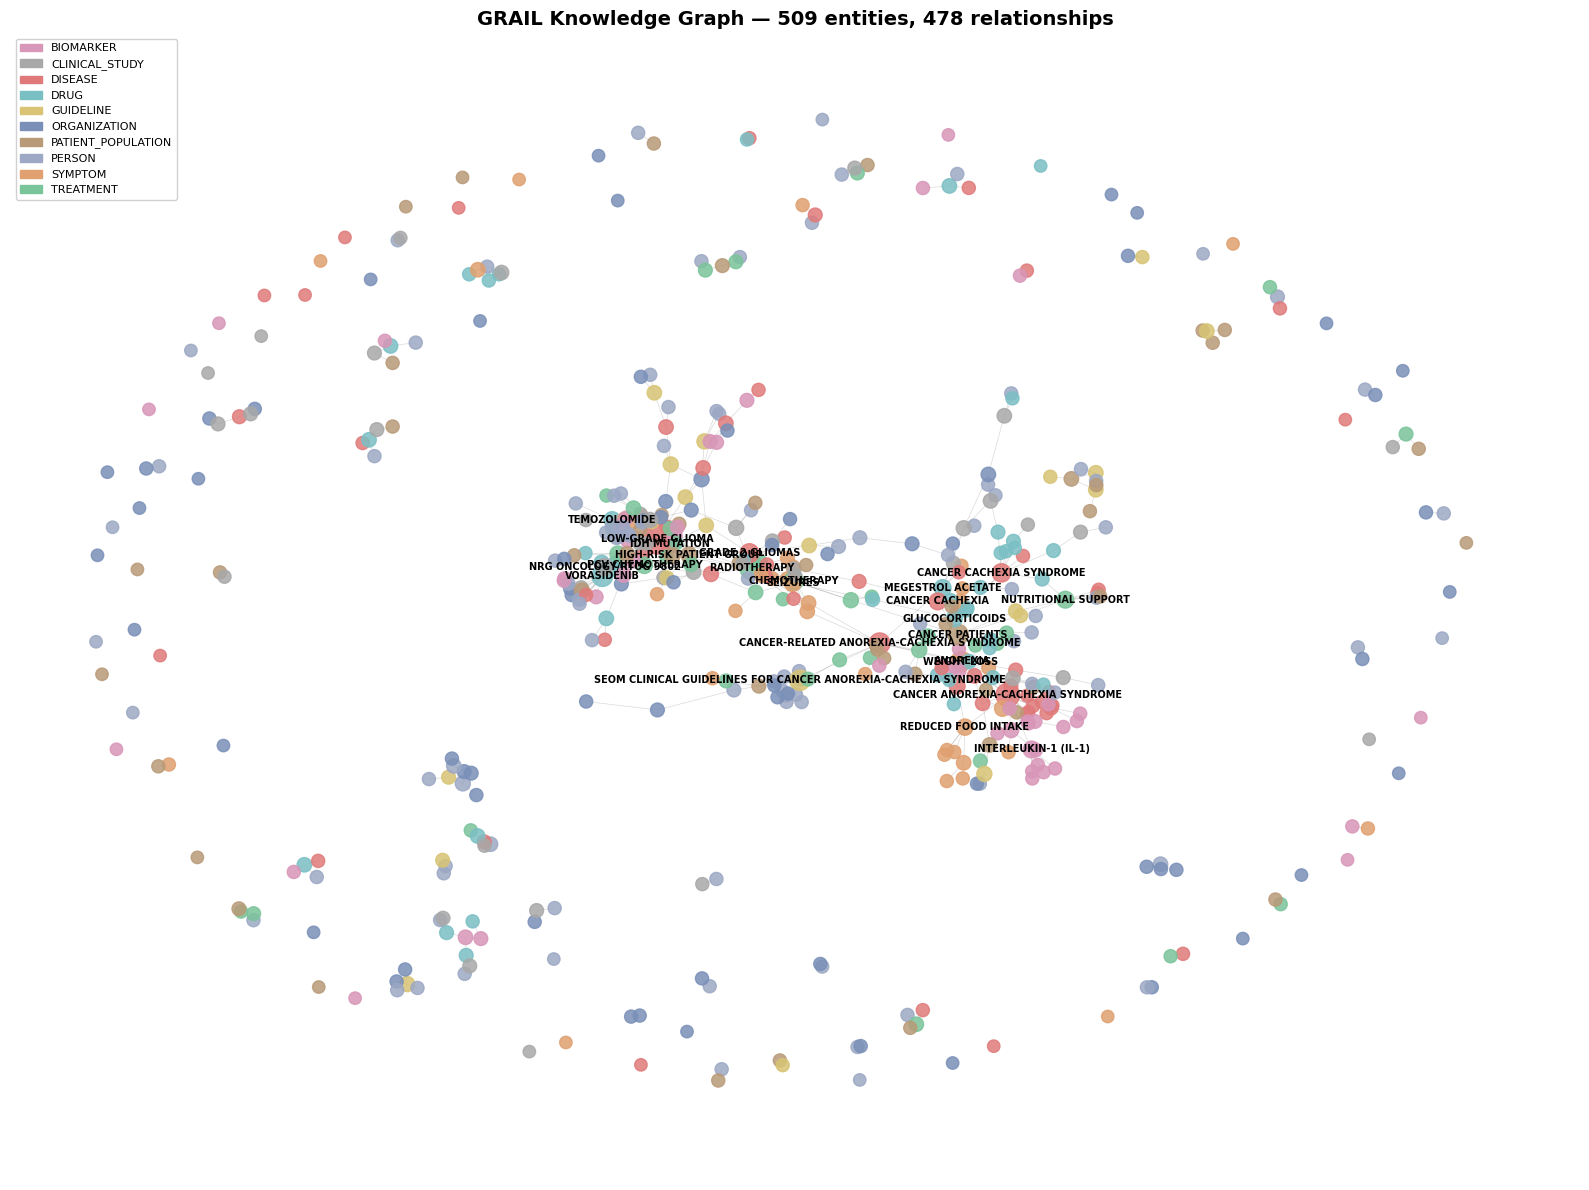

In [18]:
# Entity-type lookup for graph nodes
name_to_type = dict(zip(
    artifacts.entities["name"].str.upper(),
    artifacts.entities["type"]
))

node_colors = [type_palette.get(name_to_type.get(n.upper(), ""), "#888888") for n in G.nodes()]
node_degrees = [G.degree(n) for n in G.nodes()]
max_deg = max(node_degrees) if node_degrees else 1
node_sizes = [80 + 400 * (d / max_deg) for d in node_degrees]

fig, ax = plt.subplots(1, 1, figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=2.0 / (G.number_of_nodes() ** 0.5))

nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.85, ax=ax)

# Label only high-degree nodes to avoid clutter.
degree_threshold = sorted(node_degrees, reverse=True)[min(20, len(node_degrees) - 1)]
labels = {n: n for n in G.nodes() if G.degree(n) >= degree_threshold}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_weight="bold", ax=ax)

# Legend
patches = [mpatches.Patch(color=type_palette[t], label=t) for t in all_types]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.9)
ax.set_title(f"GRAIL Knowledge Graph — {G.number_of_nodes()} entities, {G.number_of_edges()} relationships",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

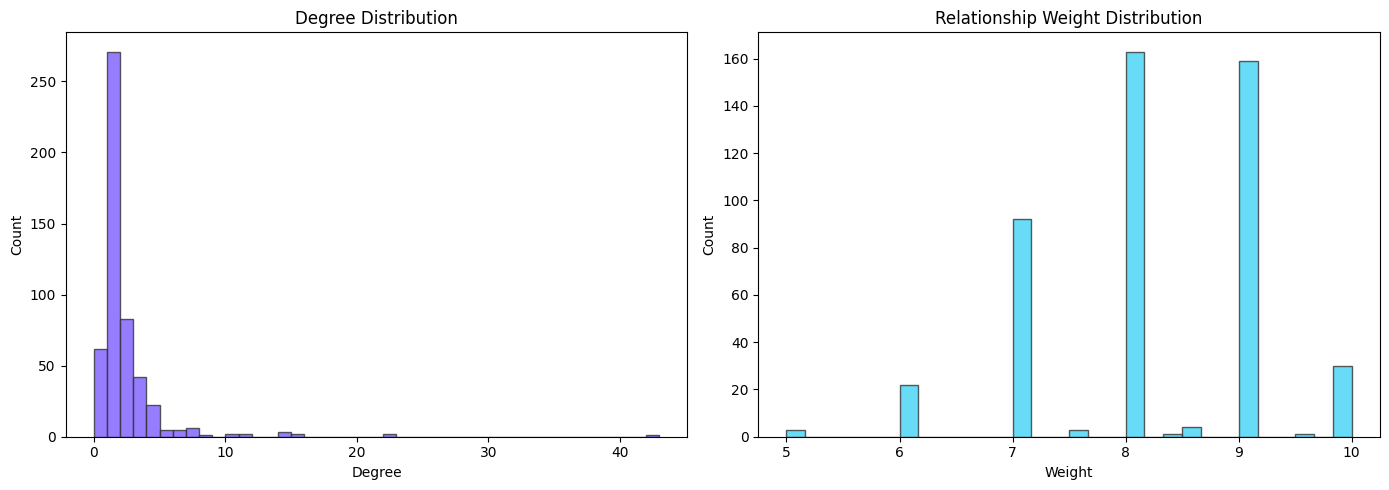

In [19]:
# Degree distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

degrees = [d for _, d in G.degree()]
axes[0].hist(degrees, bins=range(0, max(degrees) + 2), color="#7c5cff", edgecolor="#333", alpha=0.8)
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree Distribution")

# Relationship weight distribution
weights = artifacts.relationships["weight"].dropna().values
axes[1].hist(weights, bins=30, color="#42d4f4", edgecolor="#333", alpha=0.8)
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Count")
axes[1].set_title("Relationship Weight Distribution")

plt.tight_layout()
plt.show()

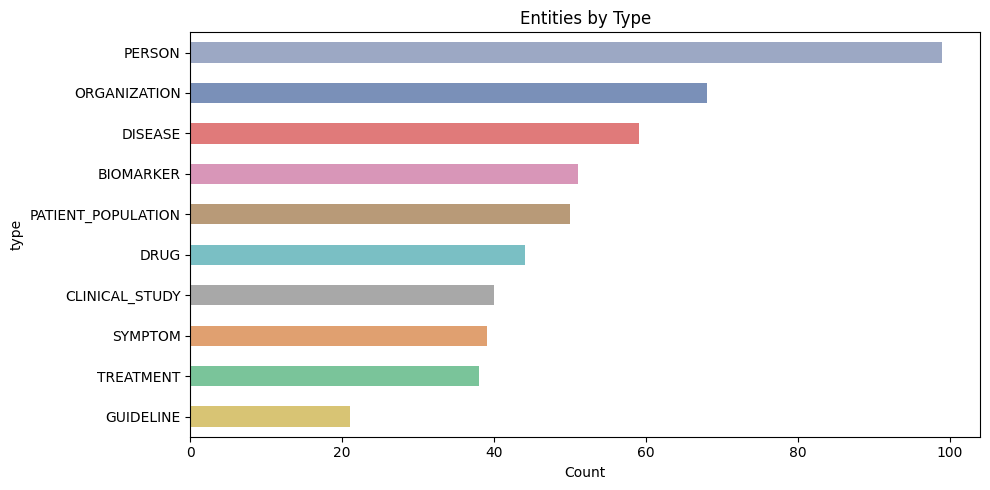

In [20]:
# Entity type distribution bar chart
type_counts = artifacts.entities["type"].value_counts()
colors = [type_palette.get(t, "#888") for t in type_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
type_counts.plot(kind="barh", color=colors, ax=ax)
ax.set_xlabel("Count")
ax.set_title("Entities by Type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Graph Visualization — pyvis (Interactive HTML)

Pyvis renders a force-directed graph in an IFrame. Hover nodes for details,
drag to rearrange. This is a quick-and-dirty interactive view; for the
production viewer see Section 8.

In [21]:
from pyvis.network import Network

# Build a pyvis graph from the NetworkX graph.
# Limit to top entities by degree to keep the visualization responsive.
MAX_NODES = 150
top_node_names = centrality_df.head(MAX_NODES)["node"].tolist()
H = G.subgraph(top_node_names).copy()

net = Network(
    height="700px",
    width="100%",
    bgcolor="#0b0d12",
    font_color="#e7eaf0",
    notebook=True,
    cdn_resources="remote",
)

net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=100)

for node in H.nodes():
    etype = name_to_type.get(node.upper(), "UNKNOWN")
    color = type_palette.get(etype, "#888888")
    deg = H.degree(node)
    size = 8 + (deg * 2)
    desc = artifacts.entities.loc[
        artifacts.entities["name"].str.upper() == node.upper(), "description"
    ]
    desc_text = desc.iloc[0][:200] if not desc.empty else ""
    title = f"<b>{node}</b><br>Type: {etype}<br>Degree: {deg}<br><br>{desc_text}"
    net.add_node(node, label=node, color=color, size=size, title=title)

for u, v, data in H.edges(data=True):
    weight = float(data.get("weight", 1.0))
    desc = str(data.get("description", ""))[:100]
    net.add_edge(u, v, value=weight, title=desc, color="#5b6478")

# Save and display
pyvis_path = str(REPO_ROOT / "notebooks" / "_pyvis_graph.html")
net.show(pyvis_path)
print(f"Interactive graph saved to: {pyvis_path}")
print(f"Showing {H.number_of_nodes()} nodes, {H.number_of_edges()} edges (top {MAX_NODES} by centrality)")

ModuleNotFoundError: No module named 'pyvis'

## 8. Sigma.js Viewer (Built-in `graph.html`)

GRAIL ships a production-quality graph viewer built on Sigma.js v3 with
community-aware layout, entity-type filtering, search, and a detail panel.

The HTML is self-contained — all data is embedded as JSON. We can either
regenerate it or display the existing one.

In [ ]:
from grail.viz import build_visualization

# Regenerate the graph.html from the latest indexed artefacts.
html_path = build_visualization(QUICKSTART)
print(f"Generated: {html_path}")
print(f"File size: {html_path.stat().st_size / 1024:.1f} KB")

In [ ]:
from IPython.display import IFrame, display, HTML

# Display the Sigma.js viewer inline.
# If running locally, this shows the full interactive viewer in the notebook.
graph_html = QUICKSTART / "graph.html"
if graph_html.exists():
    display(IFrame(src=str(graph_html), width="100%", height=700))
else:
    print(f"graph.html not found at {graph_html}. Run the cell above to generate it.")

In [ ]:
# Inspect the JSON payload embedded in graph.html.
# This shows the data structure that Sigma.js consumes.
html_content = graph_html.read_text(encoding="utf-8")
import re

match = re.search(r'const GRAPH_DATA\s*=\s*(\{.*?\});', html_content, re.DOTALL)
if match:
    graph_data = json.loads(match.group(1))
    meta = graph_data.get("meta", {})
    print("Sigma.js graph payload metadata:")
    print(f"  Entities:      {meta.get('n_entities', '?')}")
    print(f"  Relationships: {meta.get('n_relationships', '?')}")
    print(f"  Communities:   {meta.get('n_communities', '?')}")
    print(f"  Documents:     {meta.get('n_documents', '?')}")
    print(f"  Node kinds:    {meta.get('kind_counts', {})}")
    print(f"  Type palette:  {list(meta.get('type_palette', {}).keys())}")
    print(f"  Total nodes in payload: {len(graph_data.get('nodes', []))}")
    print(f"  Total edges in payload: {len(graph_data.get('edges', []))}")
else:
    print("Could not extract GRAPH_DATA from the HTML.")

## 9. Retrieval Primitives

Mirrors `TestRetrievalPrimitives` — the building blocks that local/global
search compose into the final LLM context.

In [ ]:
# test_build_entity_context
entity_text, entity_rows = build_entity_context(
    artifacts.entities.head(20), max_tokens=2000
)
assert isinstance(entity_text, str) and len(entity_text) > 0
assert isinstance(entity_rows, pd.DataFrame)
print(f"Entity context: {len(entity_text)} chars, {len(entity_rows)} entities")
print(f"\n--- First 500 chars ---\n{entity_text[:500]}")

In [ ]:
# test_build_relationship_context
names = artifacts.entities.head(5)["name"].tolist()
rel_text, rel_rows = build_relationship_context(
    artifacts.relationships, names, max_tokens=2000
)
assert isinstance(rel_text, str)
assert isinstance(rel_rows, pd.DataFrame)
print(f"Relationship context: {len(rel_text)} chars, {len(rel_rows)} rels")
print(f"\n--- First 500 chars ---\n{rel_text[:500]}")

In [ ]:
# test_build_community_context
comm_result, comm_rows = build_community_context(
    artifacts.community_reports, max_tokens=4000
)
assert comm_result
assert isinstance(comm_rows, pd.DataFrame)
text = comm_result if isinstance(comm_result, str) else "\n".join(comm_result)
print(f"Community context: {len(text)} chars, {len(comm_rows)} reports")
print(f"\n--- First 500 chars ---\n{text[:500]}")

In [ ]:
# test_build_text_unit_context
names = artifacts.entities.head(5)["name"].tolist()
tu_text, tu_rows = build_text_unit_context(
    artifacts.text_units, names, max_tokens=3000,
    documents=artifacts.documents, mapping=artifacts.mapping,
)
assert isinstance(tu_text, str)
assert isinstance(tu_rows, pd.DataFrame)
print(f"Text unit context: {len(tu_text)} chars, {len(tu_rows)} units")
print(f"\n--- First 500 chars ---\n{tu_text[:500]}")

In [ ]:
# test_map_query_to_entities
query = "cancer treatment guidelines"
emb = await grail_instance.embeddings.embed_one(query)
ranked = map_query_to_entities(
    query_embedding=emb,
    entities_df=artifacts.entities,
    top_k=10,
)
assert isinstance(ranked, pd.DataFrame)
assert len(ranked) <= 10
print(f"Mapped entities for '{query}':")
ranked[["name", "type", "degree"]]

## 10. GRAIL High-Level API

Mirrors `TestGRAILHighLevel` — exercises `grail.search()` in every mode.

In [ ]:
def show_result(result: SearchResult, label: str):
    """Display a search result with the same assertions as the integration test."""
    assert isinstance(result, SearchResult), f"{label}: expected SearchResult"
    assert isinstance(result.response, str) and len(result.response) > 0
    assert result.completion_time > 0
    assert result.llm_calls >= 1

    print(f"\n{'='*80}")
    print(f"  [{label}]  time={result.completion_time:.2f}s  llm_calls={result.llm_calls}")
    print(f"{'='*80}")
    print(result.response[:600])
    if len(result.response) > 600:
        print(f"\n... ({len(result.response)} chars total)")

    if isinstance(result.context_data, dict):
        print(f"\nContext data:")
        for k, v in result.context_data.items():
            if isinstance(v, pd.DataFrame):
                print(f"  {k}: {len(v)} rows, cols={list(v.columns)}")
            else:
                print(f"  {k}: {type(v).__name__}")

In [ ]:
# test_status
status = grail_instance.status()
assert status["project_name"] == "quickstart"
print("Project status:")
for k, v in status["artefacts"].items():
    mark = "OK" if v else "MISSING"
    print(f"  {k:20s} {mark}")
assert status["artefacts"]["entities"]
assert status["artefacts"]["reports"]

In [ ]:
# test_local_search
local_result = await grail_instance.search(
    "What are the main treatments for cancer cachexia?",
    mode="local",
)
show_result(local_result, "local_search")

In [ ]:
# test_global_search
global_result = await grail_instance.search(
    "What are the main themes covered in the indexed documents?",
    mode="global",
)
show_result(global_result, "global_search")

In [ ]:
# test_document_search
doc_result = await grail_instance.search(
    "What does this document cover?",
    mode="document",
    document="cachexia",
)
show_result(doc_result, "document_search")

In [ ]:
# test_local_search_with_conversation_history
history = [
    {"role": "user", "content": "Tell me about gliomas."},
    {"role": "assistant", "content": "Gliomas are brain tumors..."},
]
history_result = await grail_instance.search(
    "What treatments are recommended?",
    mode="local",
    conversation_history=history,
)
show_result(history_result, "local_search_with_history")

In [ ]:
# test_local_search_with_entity_filter
filtered_result = await grail_instance.search(
    "What are the guidelines?",
    mode="local",
    include_entity_names=["SEOM"],
)
show_result(filtered_result, "local_search_filtered")

## 11. Provenance Tracing

Mirrors `TestProvenance` — traces the source-document chain:
`search result -> sources (text units) -> document_ids -> mapping -> original files`

In [ ]:
provenance_result = await grail_instance.search(
    "cancer cachexia treatment", mode="local"
)
ctx = provenance_result.context_data
assert isinstance(ctx, dict)

print("Context data keys:", list(ctx.keys()))

if "sources" in ctx and isinstance(ctx["sources"], pd.DataFrame) and not ctx["sources"].empty:
    sources_df = ctx["sources"]
    docs_df = artifacts.documents
    mapping_data = artifacts.mapping

    cited_doc_ids = set()
    if "document_ids" in sources_df.columns:
        for _, row in sources_df.iterrows():
            dids = row["document_ids"]
            if isinstance(dids, list):
                cited_doc_ids.update(dids)
            elif isinstance(dids, str):
                cited_doc_ids.add(dids)

    cited_files = []
    for doc_id in cited_doc_ids:
        match = docs_df[docs_df["id"] == doc_id]
        if not match.empty:
            cited_files.append(match.iloc[0]["title"])
        elif doc_id in mapping_data:
            cited_files.append(mapping_data[doc_id].get("original_path", doc_id))

    print(f"\nCited document IDs: {cited_doc_ids}")
    print(f"Resolved files:")
    for f in cited_files:
        print(f"  - {f}")
    assert len(cited_doc_ids) > 0, "Search should cite at least one document"
else:
    print("No source rows in context (small index) — skipping.")

## 12. Cost Tracking

Mirrors `TestCostTracker` — reviews token usage and cost estimates
accumulated during this notebook session.

In [ ]:
tracker = grail_instance.cost_tracker
summary = tracker.summary(by="tag")

print("Cost summary by tag:")
for tag, info in summary.items():
    print(f"  {tag}: {info}")

total = tracker.total_cost_usd()
print(f"\nTotal cost: ${total:.6f}")
print(f"Display:    {tracker.render_total_cost()}")
print(f"Status:     {tracker.pricing_status()}")

if tracker.records:
    print(f"\nDetailed records ({len(tracker.records)} calls):")
    for r in tracker.records[:15]:
        print(f"  [{r.tag}] {r.model} in:{r.prompt_tokens} out:{r.completion_tokens} ${r.cost_usd:.6f}")
    if len(tracker.records) > 15:
        print(f"  ... and {len(tracker.records) - 15} more")

---

## Summary

This notebook exercised every layer of the GRAIL stack:

| Section | What it validates |
|---------|------------------|
| Config | YAML loading, mandatory types, pricing, endpoints |
| Storage | Root existence, mapping.json schema |
| Artifacts | Parquet column schemas, embeddings coverage |
| Graph | GraphML topology, parquet-graph cross-check, centrality |
| matplotlib | Static graph plot, degree/weight distributions, type bar chart |
| pyvis | Interactive force-directed graph in HTML |
| Sigma.js | Production viewer regeneration, IFrame embed, JSON payload inspection |
| Retrieval | Entity/relationship/community/text-unit context builders |
| Search | Local, global, document, history-aware, entity-filtered |
| Provenance | Source -> document chain tracing |
| Cost | Token usage and pricing validation |